In [25]:
import numpy as np
import cv2
import json
import csv
import pathlib
from pathlib import Path
from typing import List
import os
import re
import pickle
from collections import defaultdict
import ast
import scipy.spatial.transform
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, Image as IPImage


complete_corner_mapping = {
    "AB": ["A","B","D","C"],
    "BC": ["B","C","A","D"],
    "CD": ["C","D","B","A"],
    "DA": ["D","A","C","B"],
    "AD": ["A","D","B","C"],
    "DC": ["D","C","A","B"],
    "CB": ["C","B","D","A"],
    "BA": ["B","A","C","D"]
}

clockwise_rotation = ["AB","BC","CD","DA"]

default_corner_order = "AB"

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.0001)


def save_pipeline_status(outdir, step, video=None, frame=0, row=0):
    """Write a standardized status dict to `outdir/index.json`.

    Parameters:
    - outdir: path-like to the calibration output folder
    - step: string name of the pipeline step (can be arbitrary like 'detect' or 'corner_labelling_in_progress')
    - video: optional video name or pair-key for stereo
    - frame: numeric frame index (int)
    - row: numeric csv row index (int)
    """
    outdir = Path(outdir)
    index_path = outdir / 'index.json'
    # Load existing index if present
    if index_path.exists():
        try:
            with index_path.open() as f:
                index = json.load(f)
        except Exception:
            index = {}
    else:
        index = {}

    index['status'] = {'step': step, 'video': video, 'frame': int(frame) if frame is not None else 0, 'row': int(row) if row is not None else 0}

    # ensure minimal structure
    index.setdefault('frame_folders', index.get('frame_folders', []))
    with index_path.open('w') as f:
        json.dump(index, f, indent=2)


def dict_from_dict_or_json_file(file_or_dict):
    if type(file_or_dict) is dict:
        return file_or_dict
    else: 
        with open(file_or_dict) as jf:
            file_content = json.load(jf)
        return file_content

In [26]:
FILES_CSV_REQUIRED_FIELDS = [
    "frame",
    "file_loc",
    "stereo_partner",
    "upper_side",
    "video",
    "category",
    "stereo_calib_partners",
    "imgpoints_index",
]

def ensure_files_csv_row_defaults(row):
    if 'category' not in row or not row['category']:
        row['category'] = 'original'
    if 'upper_side' not in row or row['upper_side'] in (None, ''):
        row['upper_side'] = '-'
    if 'stereo_partner' not in row or not str(row['stereo_partner']).strip():
        row['stereo_partner'] = '[]'
    if 'stereo_calib_partners' not in row or not str(row['stereo_calib_partners']).strip():
        row['stereo_calib_partners'] = '[]'
    if 'imgpoints_index' not in row or row['imgpoints_index'] in (None,):
        row['imgpoints_index'] = ''

def write_files_csv_with_metadata(files_path, rows):
    rows = rows or []
    if not isinstance(files_path, Path):
        files_path = Path(files_path)
    if not rows:
        # still create file with headers
        with files_path.open('w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=FILES_CSV_REQUIRED_FIELDS)
            writer.writeheader()
        return
    fieldnames = []
    for row in rows:
        ensure_files_csv_row_defaults(row)
        for key in row.keys():
            if key not in fieldnames:
                fieldnames.append(key)
    for field in FILES_CSV_REQUIRED_FIELDS:
        if field not in fieldnames:
            fieldnames.append(field)
    with files_path.open('w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def parse_stereo_calib_partners(value):
    if not value:
        return []
    value = str(value).strip()
    if not value:
        return []
    try:
        parsed = json.loads(value)
    except Exception:
        try:
            parsed = ast.literal_eval(value)
        except Exception:
            return []
    return parsed if isinstance(parsed, list) else []



# Calibration of N Cameras

**Note**: This calibration procedure requires
- A rectangular checkerboard with one recognizable side:
    ```
    A             B
      |-|-|-|-|-|
      | | | | | |
      | | | | | |
    D |-|-|-|-|-| C
      visual clue
    ```
- A manually created file `video_2_frame_number.json` which annotates for each video the frame-sequences during which the checkerboard is visible in this video:
    ```json
    {
        "cam-2": {
            "sequences": [
                [129, 344],
                [1777, 2876]
            ],
            "best_sequences_idx": [1],
            "uses_mirror": 1,
        },
        "cam-3": {
            "sequences": [
                [330, 657], 
                [1355, 1552], 
                [1775, 2372], 
                [4031, 4272]
            ],
            "best_sequences_idx": [2,3],
            "uses_mirror": 0,
        },
        ...
    }
    ```


## Utility

### Drawing

In [27]:
def draw_corners_with_order(image, corners, text_color=(0, 0, 255), text_offset=(0, 0), circle_color=(0, 255, 0)):
    """Custom drawing function for detected chessboard corners."""
    corners = corners.reshape(-1, 2)  # Flatten the corners for easier indexing

    # Copy the image to draw on
    image_copy = image.copy()

    # Define font, color, and scale for drawing text
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    thickness = 1

    # Draw the corner points with their order number
    for i, corner in enumerate(corners):
        corner_position = tuple(corner.astype(int))
        cv2.circle(
            image_copy, corner_position, 2, circle_color, -1
        )  # Draw a small circle at the corner
        text_position = (int(corner_position[0] + text_offset[0]), int(corner_position[1] + text_offset[1]))
        cv2.putText(
            image_copy,
            str(i + 1),
            text_position,
            font,
            font_scale,
            text_color,
            thickness,
            cv2.LINE_AA,
        )

    return image_copy

def draw_camera(ax, C, R, color='blue', label='Camera', scale=50):
    """Draw a camera frustum at center C with rotation R."""
    w, h = 0.4, 0.3
    img_plane = np.array([
        [ w,  h, 1],
        [-w,  h, 1],
        [-w, -h, 1],
        [ w, -h, 1]
    ]) * scale

    frustum_pts = (R @ img_plane.T).T + C

    for pt in frustum_pts:
        ax.plot([C[0], pt[0]], [C[1], pt[1]], [C[2], pt[2]], color=color)

    idx = [0, 1, 2, 3, 0]
    ax.plot(frustum_pts[idx, 0], frustum_pts[idx, 1], frustum_pts[idx, 2], color=color, label=label)

### Extract from video

In [28]:
def extract_from_video(
    videos: List[Path],
    video_2_frame_number,
    out_dir: Path,
    start_video: str = None,
    start_frame: int = 0,
    frame_step: int = 1
):
    """Extract frames for multiple videos and write/update index.json and files.csv.
    If files.csv/raw_imgs already exist for a video, existing frames are preserved and
    only missing, required frames are extracted. Required frames come from
    video_2_frame_number sequences filtered by frame_step and synchronized across videos.
    Can resume extraction by passing start_video and start_frame. Adds a 'category'
    column with value 'original' for extracted frames. Flips frames horizontally if
    'uses_mirror' is set to 1 for a video in video_2_frame_number.
    """
    video_2_frame_number = dict_from_dict_or_json_file(video_2_frame_number)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    json_out_path = out_dir / "index.json"
    # If an index exists already, load it and preserve previous data
    if json_out_path.exists():
        with json_out_path.open() as f:
            json_index = json.load(f)
    else:
        json_index = {"frame_folders": [], "index_files": {}, "image_sizes": {}, "image_count": 0}
    # Ensure status field exists
    json_index.setdefault('status', {})
    video_names = [v.stem for v in videos]
    def frames_in_sequences(video_name):
        return video_2_frame_number[video_name].get("sequences", [])
    def frame_in_sequences(video_name, frame_number):
        return any(frame_number >= seq[0] and frame_number <= seq[1] for seq in frames_in_sequences(video_name))
    # === Build required frame sets (per video) with synchronization across videos ===
    required_frames_map = {v.stem: set() for v in videos}
    for video_path in videos:
        vname = video_path.stem
        for seq in frames_in_sequences(vname):
            for frame in range(seq[0], seq[1] + 1):
                if frame_step > 1 and frame % frame_step != 0:
                    continue
                if start_video is not None and vname == start_video and frame < start_frame:
                    continue
                required_frames_map[vname].add(frame)
    changed = True
    while changed:
        changed = False
        for video_path in videos:
            vname = video_path.stem
            frames_list = list(required_frames_map[vname])
            for frame in frames_list:
                for other_path in videos:
                    oname = other_path.stem
                    if oname == vname:
                        continue
                    if frame_in_sequences(oname, frame) and frame not in required_frames_map[oname]:
                        required_frames_map[oname].add(frame)
                        changed = True
    default_fields = ["frame", "file_loc", "stereo_calib_partners", "upper_side", "video", "category", "imgpoints_index", "stereo_partner"]
    for video_path in videos:
        if not video_path.exists():
            raise Exception(f"Input video does not exist: {video_path}")
        video_name = video_path.stem
        save_pipeline_status(out_dir, 'extract', video=video_name, frame=0, row=0)
        if start_video is not None:
            if video_names.index(video_name) < video_names.index(start_video):
                print(f"skipping video {video_name} before start_video {start_video}")
                continue
        uses_mirror = bool(video_2_frame_number[video_name].get("uses_mirror", False))
        print(f"processing video: {video_path}; uses_mirror={uses_mirror}")
        # read one frame to get vheight and vwidth
        capture = cv2.VideoCapture(str(video_path))
        try:
            if not capture.isOpened():
                raise ValueError(f"couldn't open video: {video_path}")
            success, frame = capture.read()
            if not success:
                raise ValueError(f"video {video_path} couldn't be read.")
            vheight, vwidth = frame.shape[:2]
        finally:
            capture.release()
        raw_imgs_dir = out_dir / video_name / "raw_imgs"
        raw_imgs_dir.mkdir(parents=True, exist_ok=True)
        files_csv_path = out_dir / video_name / "files.csv"
        rows = []
        fieldnames = None
        if files_csv_path.exists():
            with files_csv_path.open() as f:
                reader = csv.DictReader(f)
                rows = list(reader)
                fieldnames = reader.fieldnames
        if not fieldnames:
            fieldnames = default_fields.copy()
        def ensure_defaults(row_dict):
            row_dict.setdefault('frame', '')
            row_dict.setdefault('file_loc', '')
            row_dict.setdefault('stereo_calib_partners', '[]')
            row_dict.setdefault('upper_side', '-')
            row_dict.setdefault('video', video_name)
            row_dict.setdefault('category', 'original')
            row_dict.setdefault('imgpoints_index', '')
            row_dict.setdefault('stereo_partner', '[]')
            return row_dict
        rows = [ensure_defaults(dict(r)) for r in rows]
        existing_original_frames = set()
        for r in rows:
            try:
                if r.get('category') == 'original':
                    existing_original_frames.add(int(r.get('frame', -1)))
            except Exception:
                continue
        existing_images = set()
        for img_path in raw_imgs_dir.glob(f"{video_name}_*.png"):
            try:
                num = int(img_path.stem.rsplit('_', 1)[1])
                existing_images.add(num)
            except Exception:
                continue
        required_for_video = required_frames_map.get(video_name, set())
        # Add rows for required frames already present on disk but missing from files.csv
        for frame_num in sorted(required_for_video & existing_images - existing_original_frames):
            rows.append(ensure_defaults({
                'frame': str(frame_num),
                'file_loc': str(raw_imgs_dir / f"{video_name}_{frame_num}.png"),
                'video': video_name,
                'category': 'original'
            }))
            existing_original_frames.add(frame_num)
        frames_available = required_for_video & existing_original_frames & existing_images
        queue_frames = sorted(required_for_video - frames_available)
        new_rows = []
        if queue_frames:
            capture = cv2.VideoCapture(str(video_path))
            try:
                if not capture.isOpened():
                    raise ValueError(f"couldn't open video: {video_path}")
                queue_set = set(queue_frames)
                max_needed = max(queue_frames)
                frame_number = 0
                success = True
                while capture.isOpened() and success:
                    success, frame = capture.read()
                    if not success:
                        break
                    save_pipeline_status(out_dir, 'extract', video=video_name, frame=frame_number, row=0)
                    if frame_number > max_needed and not queue_set:
                        break
                    if start_video is not None and video_name == start_video and frame_number < start_frame:
                        frame_number += 1
                        continue
                    if frame_number not in queue_set:
                        frame_number += 1
                        continue
                    if uses_mirror:
                        frame = cv2.flip(frame, 1)
                    filename = f"{video_name}_{frame_number}.png"
                    abs_file_path = raw_imgs_dir / filename
                    cv2.imwrite(str(abs_file_path), frame)
                    stereo_partner = []
                    for v in video_2_frame_number:
                        if v == video_name:
                            continue
                        if frame_in_sequences(v, frame_number):
                            stereo_partner.append(v)
                    new_rows.append(ensure_defaults({
                        'frame': str(frame_number),
                        'file_loc': str(abs_file_path),
                        'video': video_name,
                        'category': 'original',
                        'stereo_partner': stereo_partner
                    }))
                    queue_set.discard(frame_number)
                    frame_number += 1
                print(f"total new images for {video_name}: {len(new_rows)}")
            finally:
                capture.release()
        rows.extend(new_rows)
        # Write combined rows back to files.csv
        all_fields = list(dict.fromkeys(fieldnames + default_fields + [k for r in rows for k in r.keys()]))
        for r in rows:
            for key in all_fields:
                r.setdefault(key, '')
        with files_csv_path.open("w", newline="") as csv_out_file:
            writer = csv.DictWriter(csv_out_file, fieldnames=all_fields)
            writer.writeheader()
            writer.writerows(rows)
        json_index["frame_folders"] = list(dict.fromkeys(json_index.get("frame_folders", []) + [video_name]))
        json_index["index_files"][video_name] = str(files_csv_path)
        json_index["image_sizes"][video_name] = [int(vwidth), int(vheight)]
        json_index["image_count"] = json_index.get("image_count", 0) + len(new_rows)
        # extraction for this video finished
        this_vid_index = json_index['frame_folders'].index(video_name)
        if this_vid_index != len(json_index['frame_folders']) - 1:
            save_pipeline_status(out_dir, 'extract', video=json_index['frame_folders'][this_vid_index+1], frame=0, row=0)
        with json_out_path.open('w') as jf:
            json.dump(json_index, jf, indent=2)
    # extraction all videos completed
    if json_index.get('frame_folders'):
        save_pipeline_status(out_dir, 'detect', video=json_index['frame_folders'][0], frame=0, row=0)
    print('Extraction complete. index.json updated at', json_out_path)


### Image and Corner Manipulations

In [29]:
def enhance_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    # enhanced = cv2.equalizeHist(gray)
    # enhanced = cv2.GaussianBlur(enhanced, (5, 5), 0)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # Sharpening
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    enhanced = cv2.filter2D(gray, -1, kernel)
    return enhanced

In [30]:
def identify_upwards_facing_edge(key_corners) -> tuple:
    """
    Identify the upwards facing side based on two criteria:
        1) It has to include the top-most corner
        2) It has to be close to horizontal
    :return: A tuple of two points (each point is an (x,y) array) that make up the upwards facing edge.
    """
    neighbours_by_index = {
        0: [key_corners[1],key_corners[2]],
        1: [key_corners[0],key_corners[3]],
        2: [key_corners[0],key_corners[3]],
        3: [key_corners[1],key_corners[2]]
    }

    # Sort by Y coordinate
    sorted_by_y = sorted(key_corners, key=lambda p: p[1])[::-1] # opencv y-coordinates are inverted
    top_most = sorted_by_y[2:4]  # Two highest corners
    top_most_corner = top_most[1]
    top_most_index = next(i for i, c in enumerate(key_corners) if np.array_equal(c, top_most_corner))

    # each edge that includes the top-most corner is a candidate for the upwards-facing side.
    facing_up_candidates = []
    if top_most[1][1] != top_most[0][1]: # if there is exactly one top most corner, i.e. the upper side is not horizontal:
        for neighbour in neighbours_by_index[top_most_index]:
            facing_up_candidates.append(tuple(sorted([top_most_corner, neighbour], key=lambda p: p[0])))  # sort left to right
    else: # in the unlikely case that the top two corners share their y-coordinate
        facing_up_candidates.append((top_most[1], top_most[0]))
    
    def compute_angle(p1, p2):
        return np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))

    minDeviation = 90  # Start with the worst possible case
    facing_up = None
    for candidate in facing_up_candidates:
        angle = compute_angle(*candidate)
        deviation = min(abs(angle), abs(180 - abs(angle)))  # Ensure we measure closeness to horizontal
        if deviation < minDeviation:
            facing_up = candidate
            minDeviation = deviation

    return facing_up


"""
The (arbitrarily chosen) corner-naming for the checkerboard looks like this:
A         B
  |-|-|-|
  | | | |
  | | | |
D |-|-|-| C
  loopbio

Based on coordinates of the imagepoints and based on a user-given ground-truth about positions of corners in the image, 
a correspondence between the above real-world corners and imgpoints is recovered.
"""
def detect_corner_order(imgpoints, cbcols, cbrows, upwards_facing_side):
    # Extract four key corners
    first = imgpoints[0]
    second = imgpoints[cbcols - 1]
    third = imgpoints[cbcols * cbrows - cbcols]
    forth = imgpoints[cbcols * cbrows - 1]
    key_corners = np.array([first, second, third, forth])
    key_corners_2_imgpoints_idx = [0, cbcols - 1, cbcols * cbrows - cbcols, cbcols * cbrows - 1]
    
    facing_up = identify_upwards_facing_edge(key_corners)
    facing_up_left  = facing_up[0] if facing_up[0][0] < facing_up[1][0] else facing_up[1]
    facing_up_right = facing_up[0] if facing_up[0][0] > facing_up[1][0] else facing_up[1]
    
    # Now, we have a correspondence between the key-corners and real-world chessboard points
    # Identify the corresponding index
    # e.g. corner order might be "BC", then facing_up_left is corner B and facing_up_right is corner C,
    #   and B might correspond to index 4 and C to index 3 in key_corners
    key_corner_index_of_facing_up_left_end = next(
        i for i, c in enumerate(key_corners) if np.all(np.isclose(c, facing_up_left))
    )
    key_corner_index_of_facing_up_right_end = next(
        i for i, c in enumerate(key_corners) if np.all(np.isclose(c, facing_up_right))
    )
    imgpoints_index_of_facing_up_left_end = key_corners_2_imgpoints_idx[key_corner_index_of_facing_up_left_end]
    imgpoints_index_of_facing_up_right_end = key_corners_2_imgpoints_idx[key_corner_index_of_facing_up_right_end]

    print(f"Upwards facing side is {upwards_facing_side}; indices of corners in imgpoints:\n{upwards_facing_side[0]}: {imgpoints_index_of_facing_up_left_end};\n{upwards_facing_side[1]}: {imgpoints_index_of_facing_up_right_end}")
    # Find out which of the 8 corner orders is the order of the currently detected imagepoints based on where in the order the upwards pointing corners are:
    corner_order = None
    for short, order in complete_corner_mapping.items():
        if order[key_corner_index_of_facing_up_left_end] == upwards_facing_side[0] and order[key_corner_index_of_facing_up_right_end] == upwards_facing_side[1]:
            corner_order = short
    print(f"This means that {corner_order[0]}, {corner_order[1]} have indices 0 and {cbcols-1} based on upwards facing side {upwards_facing_side}.\n")
            
    return corner_order
    

"""
A matrix rotation of 90 degree is a transpose with reordering.
Elements that were in a row have to be into a column after rotation, hence transpose.
If we then reverse the order within the rows (i.e. we push around columns) we get each former row (now column) to it's desired rotated position.
"""
def rotate_90_clockwise(m, iterations=1):
    for i in range(iterations):
        m = np.flip(m.transpose([1,0,2]), 0)
    return m

In [31]:
def reorder_corners(outdir, video_name, cbrows, cbcols, start_row: int = 0, visualize: bool = True):
    """Reorder detected imgpoints based on upper_side labels from files.csv.
    Updates files.csv with confirmed upper_side values after reordering.
    Returns processed obj/imgpoints lists ready for calibration.
    If visualize is True, updated imgpoints are rendered back onto visualization images.
    Can resume from start_row index in files.csv.

    :param start_row: First cb_detected row index in files.csv to start from (for resuming). If start_row=0, starts from first cb_detected row.
    """
    outdir = Path(outdir)
    
    # Load index and files.csv
    index_path = outdir / 'index.json'
    with index_path.open() as f:
        index = json.load(f)
    
    files_csv = Path(index['index_files'][video_name])
    files_data = []
    with files_csv.open() as f:
        reader = csv.DictReader(f)
        files_data = list(reader)
    for row in files_data:
        ensure_files_csv_row_defaults(row)

    # Load imgpoints
    imgpoints_path = Path(index['imgpoints'][video_name])
    with imgpoints_path.open() as f:
        imgpoints = json.load(f)

    # prepare object points template
    objp = np.zeros((cbrows*cbcols,3), np.float32)
    rows_grid, cols_grid = np.mgrid[0:cbrows, 0:cbcols]
    objp[:, 0] = cols_grid.reshape(-1)
    objp[:, 1] = rows_grid.reshape(-1)

    # Create frame_number -> row_idx mapping for updates
    frame_to_row = {int(row['frame']): i for i, row in enumerate(files_data)}

    processed_objpoints = []
    processed_imgpoints = []

    if start_row == 0:
        # Find first cb_detected row
        for i, row in enumerate(files_data):
            if row.get('category', '') == 'cb_detected':
                start_row = i
                break

    # Process each frame in files.csv order, starting at start_row
    for idx in range(start_row, len(files_data)):
        row = files_data[idx]
        if row.get("category") == "bad_detection":
            continue
        filename = os.path.splitext(os.path.basename(row['file_loc']))[0]
        if filename not in imgpoints:
            continue  # skip frames where no corners were detected
        points = np.array(imgpoints[filename])
        upper_side = row.get('upper_side', '-')
        
        # If no upper_side label, include points as-is for calibration
        if upper_side == '-' or not upper_side:
            imgp_ordered = points.reshape(cbrows*cbcols, 2)
        else:
            # detect current corner order and rotate/reorient as needed
            this_corner_order = detect_corner_order(points, cbrows=cbrows, cbcols=cbcols, upwards_facing_side=upper_side)
            imgpt2 = np.copy(points).reshape(cbrows,cbcols,2)
            if this_corner_order is not None:
                if this_corner_order not in clockwise_rotation:
                    # we assume this is a mirrored order
                    imgpt2 = np.flip(imgpt2, 1)
                    this_corner_order = this_corner_order[::-1]
                rotate_count = 0
                labelled_corner_order = this_corner_order
                while this_corner_order != default_corner_order:
                    index_rot = clockwise_rotation.index(this_corner_order)
                    imgpt2 = rotate_90_clockwise(imgpt2, iterations=1)
                    index_rot = (index_rot-1) % len(clockwise_rotation)
                    this_corner_order = clockwise_rotation[index_rot]
                    rotate_count += 1
                print(f"{row['frame']}: rotated imgpoints by {rotate_count * 90} degrees clockwise to rotate indices 0, {cbcols-1} from {labelled_corner_order[0]}, {labelled_corner_order[1]} to the desired default side {default_corner_order}.")
                
                # Confirm the upper_side in files.csv now that we've validated it works
                frame_num = int(row['frame'])
                if frame_num in frame_to_row:
                    files_data[frame_to_row[frame_num]]['upper_side'] = upper_side
                
            imgp_ordered = imgpt2.reshape(cbrows*cbcols,2)

        if visualize and row.get('category') == 'cb_detected':
            vis_path = Path(row['file_loc'])
            if vis_path.exists():
                print(f"Writing reordered corner visualization for frame {row['frame']} to {vis_path.stem + '_reordered' + vis_path.suffix}")
                img_vis = cv2.imread(str(vis_path))
                if img_vis is not None:
                    ordered_pts = np.array(imgp_ordered, dtype=np.float32)
                    updated = draw_corners_with_order(
                        img_vis, ordered_pts, text_color=(255, 255, 0), text_offset=(-17, 15)
                    )
                    cv2.imwrite(str(vis_path.with_suffix(""))+"_reordered.jpg", updated)

        processed_objpoints.append(objp.tolist())
        processed_imgpoints.append(imgp_ordered.tolist())
        if row.get('category') == 'cb_detected':
            row['imgpoints_index'] = str(len(processed_imgpoints) - 1)

        # update status in index.json so pipeline can resume mid-reorder
        save_pipeline_status(outdir, 'reorder', video=video_name, frame=int(row['frame']), row=idx)

    # Save processed points
    video_dir = outdir / video_name
    proc_objpoints_path = video_dir / 'processed_objpoints.json'
    proc_imgpoints_path = video_dir / 'processed_imgpoints.json'
    
    with proc_objpoints_path.open('w') as f:
        json.dump(processed_objpoints, f)
    with proc_imgpoints_path.open('w') as f:
        json.dump(processed_imgpoints, f)

    write_files_csv_with_metadata(files_csv, files_data)

    # Update index.json to track processed points
    if 'imgpoints_processed' not in index:
        index['imgpoints_processed'] = {}
    index['imgpoints_processed'][video_name] = {
        'objpoints': str(proc_objpoints_path),
        'imgpoints': str(proc_imgpoints_path)
    }
    with index_path.open('w') as f:
        json.dump(index, f, indent=2)
    save_pipeline_status(outdir, 'calibrate', video=index['frame_folders'][0], frame=0, row=0)

    return processed_objpoints, processed_imgpoints

## Checkerboard Detection

In [32]:
def detect_checkerboards(outdir, video_name, cbrows, cbcols, enhance=True, start_row: int = 0):
    """Detect checkerboards in images from files.csv, track results in index.json.
    Uses files.csv for frame numbers and updates it with upper_side labels.
    Can resume from a given row index in files.csv by passing start_row.
    Marks frames that need user labeling by setting upper_side to "!" in files.csv and
    adds 'cb_detected' category entries to files.csv for visualizations created.
    """
    outdir = Path(outdir)
    index_path = outdir / 'index.json'
    with index_path.open() as f:
        index = json.load(f)

    # Load files.csv for this video
    files_csv = Path(index['index_files'][video_name])
    files_data = []
    with files_csv.open() as f:
        reader = csv.DictReader(f)
        files_data = list(reader)

    # Ensure 'category' column exists; default missing values to 'original'
    for r in files_data:
        if 'category' not in r or not r['category']:
            r['category'] = 'original'
        # reset upper_side to allow re-detection
        r['upper_side'] = '-'
        if 'stereo_partner' not in r or not r['stereo_partner']:
            r['stereo_partner'] = '[]'
        if 'imgpoints_index' not in r:
            r['imgpoints_index'] = ''

    # Build a queue: original rows that do not yet have a corresponding 'cb_detected' entry
    existing_cb_basenames = set()
    for r in files_data:
        if r.get('category') == 'cb_detected':
            existing_cb_basenames.add(os.path.basename(r['file_loc']))

    original_rows = [ (i, r) for i, r in enumerate(files_data) if r.get('category') == 'original' ]
    queue = []
    first_row_i = 10e6
    for i, r in original_rows:
        orig_basename = os.path.basename(r['file_loc'])
        if orig_basename not in existing_cb_basenames:
            if i < first_row_i:
                first_row_i = i
            queue.append((i, r))

    # criteria for corner detection
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

    # prepare object points template
    objp = np.zeros((cbcols*cbrows,3), np.float32)
    rows_grid, cols_grid = np.mgrid[0:cbrows, 0:cbcols]
    objp[:, 0] = cols_grid.reshape(-1)
    objp[:, 1] = rows_grid.reshape(-1)

    # Arrays to store object points and image points from all the images.
    objpoints = {} # 3d point in real world space
    imgpoints = {} # 2d points in image plane.

    prev_upper_side_indices = None
    changed_frames = []  # list of (filename, frame_number, row_idx)

    video_dir = outdir / video_name
    vis_dir = video_dir / 'visualizations'
    vis_dir.mkdir(parents=True, exist_ok=True)

    print(f"Found {len(queue)} original frames that need cb detection (rows in files.csv).")

    # Process the queue (only entries missing cb_detected)
    for i, row in queue:
        fpath = row['file_loc']
        frame_num = int(row['frame'])
        filename = os.path.splitext(os.path.basename(fpath))[0]

        # update status
        save_pipeline_status(outdir, 'detect', video=video_name, frame=frame_num, row=i)

        img = cv2.imread(fpath)
        if img is None:
            print(f"Could not read {fpath}; skipping")
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if enhance:
            gray = enhance_image(gray)

        # openCV findchessboardcorners works with (columns, rows)
        # corners are placed in the output array a certain order (row by row, left to right in every row)
        try:
            ret, corners = cv2.findChessboardCornersSB(gray, (cbcols,cbrows), None)
        except Exception:
            ret, corners = cv2.findChessboardCorners(gray, (cbcols,cbrows), None)

        if not ret:
            # No corners found: skip creating cb_detected entry but keep original row
            continue

        # corners found: refine and save
        try:
            corners2 = cv2.cornerSubPix(gray,corners, (cbcols-1,cbrows-1), (-1,-1), criteria)
        except Exception:
            corners2 = corners

        objpoints[filename] = objp.tolist()
        imgpoints[filename] = corners2.tolist()
        imgpoints[filename] = [point[0] for point in imgpoints[filename]] # remove one unnecessary dimension in the array (points were unnecessarily stored as [[x,y]] instead of [x,y])

        # Compute edge orientation and mark '!' on the original row if angle changes
        first = imgpoints[filename][0]
        second = imgpoints[filename][cbcols - 1]
        third = imgpoints[filename][cbcols * cbrows - cbcols]
        forth = imgpoints[filename][cbcols * cbrows - 1]
        key_corners = np.array([first, second, third, forth])

        facing_up = identify_upwards_facing_edge(key_corners)
        p1, p2 = facing_up

        # NOTE: we determine if an upper side change has occurred by tracking the indices of the two corners that make up the upwards facing edge.
        # usually, the upwards-facing edge will change to a neighbouring edge, meaning there is going to be a different number of corners.
        # this way, the indices of the two corners that make up the upwards-facing edge will change.
        # the only exception is when the checkerboard rotates 180 degrees, in which case the upwards-facing edge will be the same as before but flipped.
        # However, we assume a sufficiently high frame rate so that a 180 degree rotation between frames is unlikely.
        index_of_facing_up_left_end = next(
            i for i, c in enumerate(imgpoints[filename]) if np.all(np.isclose(c, p1))
        )
        index_of_facing_up_right_end = next(
            i for i, c in enumerate(imgpoints[filename]) if np.all(np.isclose(c, p2))
        )

        if index_of_facing_up_left_end != prev_upper_side_indices[0] or index_of_facing_up_right_end != prev_upper_side_indices[1] if prev_upper_side_indices is not None else True:
            # mark the ORIGINAL row for manual labeling
            files_data[i]['upper_side'] = '!'
            changed_frames.append((os.path.basename(fpath), frame_num, i))

        print(f"Frame {frame_num}: upwards facing edge corners indices: {index_of_facing_up_left_end}, {index_of_facing_up_right_end}\n(previous: {prev_upper_side_indices})\n")

        prev_upper_side_indices = (index_of_facing_up_left_end, index_of_facing_up_right_end)


        # create visualization
        color_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR) if len(gray.shape) == 2 else img.copy()
        first_corner = (int(corners2[0][0][0]), int(corners2[0][0][1]))
        last_corner = (int(corners2[-1][-1][0]), int(corners2[-1][-1][1]))
        cv2.putText(color_img, '0', first_corner, cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
        cv2.putText(color_img, str(len(corners2) - 1), last_corner, cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
        color_img = draw_corners_with_order(color_img, corners2)
        cv2.line(color_img, np.int32(p1), np.int32(p2), (255, 255, 0), 2)

        vis_name = os.path.basename(fpath)
        vis_path = vis_dir / vis_name
        cv2.imwrite(str(Path(vis_path).with_suffix(".jpg")), color_img)

        # Append a new files.csv entry for this detection with category 'cb_detected'
        new_row = {
            'frame': row['frame'],
            'file_loc': str(vis_path),
            'stereo_partner': row.get('stereo_partner', '[]'),
            'upper_side': row.get('upper_side', '-') ,
            'video': video_name,
            'category': 'cb_detected',
            'stereo_calib_partners': row.get('stereo_partners', '[]'),
            'imgpoints_index': row.get('imgpoints_index', '')
        }
        files_data.append(new_row)

    # After processing queue, save detected points and write files.csv
    video_dir.mkdir(exist_ok=True)
    objpoints_path = video_dir / 'objpoints.json'
    imgpoints_path = video_dir / 'imgpoints.json'
    with objpoints_path.open('w') as f:
        json.dump(objpoints, f)
    with imgpoints_path.open('w') as f:
        json.dump(imgpoints, f)

    write_files_csv_with_metadata(files_csv, files_data)

    # Update index.json to track imgpoints and mark that corner-correction may be pending
    if 'imgpoints' not in index:
        index['imgpoints'] = {}
    index['imgpoints'][video_name] = str(imgpoints_path)
    with index_path.open('w') as f:
        json.dump(index, f, indent=2)
    save_pipeline_status(outdir, 'corner_labelling', video=index['frame_folders'][0], frame=0, row=0)

    return objpoints, imgpoints

In [33]:
def label_upper_side(outdir, video_name, start_row: int = 0, default_label="BC", review_frames: bool = False):
    """
    Works on cb_detected entries in files.csv that correspond to original entries marked with '!' in upper_side.
    If review_frames is True, you can mark bad detections to exclude from calibration.
    
    :param outdir: Description
    :param video_name: Description
    :param start_row: First cb_detected row index to start from (for resuming). If start_row=0, starts from first cb_detected row.
    :type start_row: int
    :param default_label: Description
    """
    outdir = Path(outdir)
    index_path = outdir / 'index.json'
    with index_path.open() as f:
        index = json.load(f)

    files_csv = Path(index['index_files'][video_name])
    with files_csv.open() as f:
        reader = csv.DictReader(f)
        files_data = list(reader)

    video_dir = outdir / video_name
    vis_dir = video_dir / 'visualizations'

    # Select rows that need user labeling: only cb_detected rows that have a corresponding original row marked '!'
    marked_frames_orig = [int(r['frame']) for r in files_data
                   if r.get('upper_side', '!') == '!' and r.get('category', '') == 'original']
    marked_cb_detected_rows = [i for i, r in enumerate(files_data)
                   if int(r['frame']) in marked_frames_orig and r.get('category', '') == 'cb_detected']
    # always label the very first cb_detected row too
    first_idx = min(files_data.index(r) for r in files_data if r['category'] == 'cb_detected')
    marked_cb_detected_rows.insert(0, first_idx)

    # start_row == 0 means process everything
    if start_row == 0:
        # find first marked row
        for r in marked_cb_detected_rows:
            if r >= 0:
                start_row = r
                break
    # support resume
    if start_row > 0:
        marked_cb_detected_rows = [r for r in marked_cb_detected_rows if r >= start_row]
        print(f"Resuming from row {start_row}, {len(marked_cb_detected_rows)} rows left to label.")

    if not marked_cb_detected_rows:
        print(f"No frames marked for correction for {video_name} (start_row={start_row}).")
        this_vid_index = index['frame_folders'].index(video_name)
        if this_vid_index == len(index['frame_folders']) - 1:
            save_pipeline_status(outdir, 'calibrate', video=index['frame_folders'][0], frame=0, row=0)
        else:
            save_pipeline_status(outdir, 'reorder', video=index['frame_folders'][this_vid_index+1], frame=0, row=0)
        return files_csv

    print(f"\nFound {len(marked_cb_detected_rows)} frames to label (starting at row {start_row}).")
    complete_corner_mapping_set = {"AB","BC","CD","DA","BA","CB","DC","AD"}

    def persist_files_and_index(last_row_idx=None, in_progress=False):
        # persist CSV
        with files_csv.open('w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=files_data[0].keys())
            writer.writeheader()
            writer.writerows(files_data)
        # persist index
        if in_progress:
            save_pipeline_status(outdir, 'reorder', video=video_name, frame=0, row=last_row_idx)
        else:
            this_vid_index = index['frame_folders'].index(video_name)
            if this_vid_index == len(index['frame_folders']) - 1:
                save_pipeline_status(outdir, 'calibrate', video=index['frame_folders'][0], frame=0, row=0)
            else:
                save_pipeline_status(outdir, 'reorder', video=index['frame_folders'][this_vid_index+1], frame=0, row=0)

    for n, idx in enumerate(marked_cb_detected_rows, start=1):
        clear_output(wait=True)
        row = files_data[idx]
        # choose a friendly frame label: try a few possible keys
        frame_identifier = str(' ').join([row.get('frame', ''), row.get('file_loc', '')])
        print(f"[{n}/{len(marked_cb_detected_rows)}] Row {idx} â€” Frame {frame_identifier}")
        # pick visualization if available
        vis_path = vis_dir / os.path.basename(row.get('file_loc', ''))
        if vis_path.exists():
            display(IPImage(filename=str(vis_path)))
        else:
            imgfile = Path(row.get('file_loc', ''))
            if imgfile.exists():
                display(IPImage(filename=str(imgfile)))
            else:
                print("âš  Image not found (showing file path):", row.get('file_loc', ''))

        # prompt user
        prompt = (f"""Enter upwards-facing side corners for {frame_identifier} (e.g. AB); always label from left corner to right corner.\n
                  The (arbitrarily chosen) corner-naming for the checkerboard looks like this:
                    A         B
                      |-|-|-|
                      | | | |
                      | | | |
                    D |-|-|-| C
                    visual clue"""
                  f"Type 'q' to quit and save progress.")
        
        try:
            user_input = input(prompt).strip().upper()
        except KeyboardInterrupt:
            print("\nInterrupted by user â€” saving progress and exiting.")
            persist_files_and_index(last_row_idx=idx, in_progress=True)
            return files_csv

        if user_input in ('Q', 'QUIT', 'EXIT'):
            print("Quit requested. Saving progress...")
            persist_files_and_index(last_row_idx=idx, in_progress=True)
            return files_csv

        if user_input == "":
            user_input = default_label
        user_input = user_input[:2]  # keep only first two chars
        if user_input not in complete_corner_mapping_set:
            print(f"âš  Warning: '{user_input}' not in canonical set, saving anyway.")

        # find next marked row > idx
        next_mark = next((m for m in marked_cb_detected_rows if m > idx), None)
        end_idx = next_mark if next_mark is not None else len(files_data)
        # assign label for rows idx .. end_idx-1
        for r in range(idx, end_idx):
            files_data[r]['upper_side'] = user_input

        # persist after each assignment
        persist_files_and_index(last_row_idx=end_idx - 1, in_progress=True)
        print(f"Saved label '{user_input}' for rows {idx}..{end_idx-1}")

    if review_frames:
        user_input = input("Enter comma-separated frame numbers or ranges to exclude (e.g. 50-67,70,82). Leave blank to skip: ").strip()
        bad_frames = set()
        for token in re.split(r"[\s,]+", user_input):
            token = token.strip()
            if not token:
                continue
            if "-" in token:
                try:
                    start_str, end_str = token.split("-", 1)
                    start = int(start_str)
                    end = int(end_str)
                except Exception:
                    print(f"Skipping invalid range entry: {token}")
                    continue
                lo, hi = (start, end) if start <= end else (end, start)
                bad_frames.update(range(lo, hi + 1))
            else:
                try:
                    bad_frames.add(int(token))
                except Exception:
                    print(f"Skipping invalid frame entry: {token}")
        if bad_frames:
            for r in files_data:
                try:
                    frame_val = int(r.get("frame", -1))
                except Exception:
                    continue
                if frame_val in bad_frames:
                    r["category"] = "bad_detection"
                    r["imgpoints_index"] = ""
            print(f"Marked {len(bad_frames)} frames as bad_detection: {sorted(bad_frames)}")
        else:
            print("No frames marked as bad_detection.")

    # finalize
    persist_files_and_index(in_progress=False)
    clear_output(wait=True)
    print(f"âœ“ Corner-order correction complete for {video_name}.")
    return files_csv

## Calibration

In [34]:
def calibrate_camera_from_processed(outdir, video_name, image_size):
    """Calibrate a single camera from processed points and update index.json with results."""
    outdir = Path(outdir)
    
    # Load index
    with (outdir / 'index.json').open() as f:
        index = json.load(f)

    # Get paths to processed points
    proc_paths = index['imgpoints_processed'][video_name]
    with open(proc_paths['objpoints']) as f:
        objpoints_list = json.load(f)
    with open(proc_paths['imgpoints']) as f:
        imgpoints_list = json.load(f)

    # Convert to numpy arrays
    objpoints = np.array(objpoints_list, dtype=np.float32)
    imgpoints = np.array(imgpoints_list, dtype=np.float32)

    # Run calibration
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, tuple(image_size), None, None, criteria=criteria)

    calibration_data = {
        "video_name": video_name,
        "ret": float(ret),
        "mtx": mtx.tolist(),
        "dist": dist.tolist(),
        "rvecs": [r.tolist() for r in rvecs],
        "tvecs": [t.tolist() for t in tvecs],
    }

    # Save calibration parameters
    calib_dir = outdir / 'calibration'
    calib_dir.mkdir(exist_ok=True)
    calib_path = calib_dir / f"{video_name}_calibration.json"
    
    with calib_path.open('w') as f:
        json.dump(calibration_data, f, indent=4)

    # Update index.json to track calibration file
    if 'calib' not in index:
        index['calib'] = {}
    index['calib'][video_name] = str(calib_path)
    
    with (outdir / 'index.json').open('w') as f:
        json.dump(index, f, indent=2)

    print(f"Saved calibration for {video_name} to {calib_path}")
    return calibration_data

def stereo_calibrate(outdir, video1, video2, files_csv1, files_csv2, processed_paths1, processed_paths2):
    """Run stereo calibration for a pair using overlapping cb_detected frames only."""
    outdir = Path(outdir)
    files_csv1 = Path(files_csv1)
    files_csv2 = Path(files_csv2)

    with (outdir / 'index.json').open() as f:
        index = json.load(f)

    def load_calibration(video):
        with open(index['calib'][video]) as f:
            return json.load(f)

    calib1 = load_calibration(video1)
    calib2 = load_calibration(video2)

    def load_processed(processed_paths):
        with open(processed_paths['objpoints']) as f:
            objpoints = json.load(f)
        with open(processed_paths['imgpoints']) as f:
            imgpoints = json.load(f)
        return objpoints, imgpoints

    objpoints1, imgpoints1 = load_processed(processed_paths1)
    objpoints2, imgpoints2 = load_processed(processed_paths2)

    def load_files_rows(csv_path):
        with csv_path.open() as f:
            reader = csv.DictReader(f)
            rows = list(reader)
        rows = [r for r in rows if r.get('category') == 'cb_detected']
        for row in rows:
            ensure_files_csv_row_defaults(row)
        return rows

    rows1 = load_files_rows(files_csv1)
    rows2 = load_files_rows(files_csv2)

    def build_cb_lookup(rows):
        """:return: A dict mapping frame numbers to a dict with 'row_idx' and 'img_idx'."""
        lookup = {}
        for idx, row in enumerate(rows):
            frame = int(row.get('frame', -1))
            imgpts_idx = int(row.get('imgpoints_index', ''))
            if imgpts_idx < 0:
                continue
            lookup[frame] = {'row_idx': idx, 'img_idx': imgpts_idx}
        return lookup

    frame1_2_row_x_imgpts = build_cb_lookup(rows1)
    frame2_2_row_x_imgpts = build_cb_lookup(rows2)

    def set_partner(rows, row_idx, partner_video, partner_frame, partner_index):
        """In the given row (of files.csv), set/update the stereo_calib_partners field to include the given partner info."""
        row = rows[row_idx]
        partners = parse_stereo_calib_partners(row.get('stereo_calib_partners', ''))
        partners = [p for p in partners if p.get('video') != partner_video]
        partners.append({'video': partner_video, 'frame': partner_frame, 'imgpoints_index': partner_index})
        row['stereo_calib_partners'] = json.dumps(partners)

    filtered_objpoints = []
    filtered_imgpoints1 = []
    filtered_imgpoints2 = []

    matched_count = 0
    for frame, row_and_imgpts_1 in frame1_2_row_x_imgpts.items():
        row_and_imgpts_2 = frame2_2_row_x_imgpts.get(frame)
        if not row_and_imgpts_2:
            continue
        imgpts_idx_1 = row_and_imgpts_1['img_idx']
        imgpts_idx_2 = row_and_imgpts_2['img_idx']
        if imgpts_idx_1 >= len(imgpoints1) or imgpts_idx_2 >= len(imgpoints2):
            continue
        filtered_objpoints.append(objpoints1[imgpts_idx_1])
        filtered_imgpoints1.append(imgpoints1[imgpts_idx_1])
        filtered_imgpoints2.append(imgpoints2[imgpts_idx_2])
        set_partner(rows1, row_and_imgpts_1['row_idx'], video2, frame, imgpts_idx_2)
        set_partner(rows2, row_and_imgpts_2['row_idx'], video1, frame, imgpts_idx_1)
        matched_count += 1

    if not matched_count:
        print(f"No overlapping cb_detected frames found between {video1} and {video2}.")
        return

    write_files_csv_with_metadata(files_csv1, rows1)
    write_files_csv_with_metadata(files_csv2, rows2)

    filtered_objpoints = np.array(filtered_objpoints, dtype=np.float32)
    filtered_imgpoints1 = np.array(filtered_imgpoints1, dtype=np.float32)
    filtered_imgpoints2 = np.array(filtered_imgpoints2, dtype=np.float32)

    size1 = np.array(index['image_sizes'][video1])
    size2 = np.array(index['image_sizes'][video2])

    mtx1 = np.array(calib1['mtx'])
    dist1 = np.array(calib1['dist'])
    mtx2 = np.array(calib2['mtx'])
    dist2 = np.array(calib2['dist'])

    # R: Output rotation matrix. Together with the translation vector T, 
    # this matrix brings points given in the first camera's coordinate system 
    # to points in the second camera's coordinate system. 
    # In more technical terms, the tuple of R and T performs a change of basis 
    # from the first camera's coordinate system to the second camera's coordinate system. 
    # Due to its duality, this tuple is equivalent to the position of the first camera 
    # with respect to the second camera coordinate system.
    retval, cameraMatrix1, distCoeffs1, cameraMatrix2, distCoeffs2, R, T, E, F = (
        cv2.stereoCalibrate(
            filtered_objpoints,
            filtered_imgpoints1,
            filtered_imgpoints2,
            mtx1,
            dist1,
            mtx2,
            dist2,
            size1[::-1],
            flags=cv2.CALIB_FIX_INTRINSIC,
        )
    )

    # Fix rotation direction
    R_flipX = cv2.Rodrigues(np.array([np.pi, 0, 0]))[0]
    R_fixed = R @ R_flipX
    R = R_fixed
    T = -T

    # Plot relationship
    r = scipy.spatial.transform.Rotation.from_matrix(R)
    angles_deg = r.as_euler("xyz", degrees=True)
    print("Rotation (degrees):", angles_deg)
    print("Translation vector:", T.ravel())
    print(f"Using {matched_count} matched frames for stereo calibration.")

    # === Plot camera setup ===
    C1 = np.array([0, 0, 0])
    R1 = np.eye(3)
    C2 = -R.T @ T # R, T are camera1 w.r.t. camera2, so invert to get camera2 w.r.t. camera1
    R2 = R

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    draw_camera(ax, C1, R1, color="blue", label=f"Camera {video1}")
    draw_camera(ax, C2.ravel(), R2, color="red", label=f"Camera {video2}")
    ax.plot([C1[0], C2[0][0]], [C1[1], C2[1][0]], [C1[2], C2[2][0]], "k--", label="Baseline")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"Stereo Setup: {video1} - {video2}")
    ax.legend()
    ax.view_init(elev=20, azim=45)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    # Calculate projection matrices
    K1 = cameraMatrix1
    K2 = cameraMatrix2
    R1 = np.eye(3)
    t1 = np.zeros((3, 1))
    P1 = K1 @ np.hstack((R1, t1))
    P2 = K2 @ np.hstack((R2, T))

    stereo_calibration_data = {
        "perspective_name": f"{video1}__{video2}",
        "matched_frames": matched_count,
        "ret": float(retval),
        "CM1": cameraMatrix1.tolist(),
        "dist1": distCoeffs1.tolist(),
        "CM2": cameraMatrix2.tolist(),
        "dist2": distCoeffs2.tolist(),
        "R": R.tolist(),
        "T": T.tolist(),
        "E": E.tolist(),
        "F": F.tolist(),
        "P1": P1.tolist(),
        "P2": P2.tolist(),
    }

    stereo_dir = outdir / 'stereo'
    stereo_dir.mkdir(exist_ok=True)
    stereo_path = stereo_dir / f"{video1}__{video2}_stereo.json"
    
    with stereo_path.open('w') as f:
        json.dump(stereo_calibration_data, f, indent=4)

    if 'stereo_calib' not in index:
        index['stereo_calib'] = {}
    index['stereo_calib'][f"{video1}__{video2}"] = str(stereo_path)
    
    with (outdir / 'index.json').open('w') as f:
        json.dump(index, f, indent=2)

    print(f"Stereo calibration saved to {stereo_path}")
    return stereo_calibration_data

## Usage

In [ ]:
def calibrate_videos(videos, video_2_frame_number, outdir, cbrows, cbcols, frame_step=1, reorder_visualize=False, review_frames=False, steps_to_perform=None, videos_to_process=None):
    """Full calibration pipeline that can resume using index.json status.

    Behavior:
      - Steps and videos are ordered. Status indicates the (step, video[, frame/row])
        location where processing should resume (i.e. the current video still needs
        processing starting at the given frame/row).
      - The pipeline skips earlier videos/frames and resumes at that point.
      - Steps: extract -> detect -> corner_labelling -> reorder -> calibrate -> stereo
      - Set reorder_visualize=True to overwrite visualization images with the reordered indices.
      - Set review_frames=True to mark bad detections to exclude after corner labelling.
      - Pass steps_to_perform and/or videos_to_process to filter what runs; these are not stored in status.
    """
    outdir = Path(outdir)
    videos = [Path(v) for v in videos]
    index_path = outdir / 'index.json'

    steps = ['extract', 'detect', 'corner_labelling', 'reorder', 'calibrate', 'stereo']

    def parse_filter_list(value):
        if isinstance(value, list):
            return [v for v in value if isinstance(v, str)]
        if isinstance(value, str) and value:
            return [value]
        return []

    steps_filter = set() if steps_to_perform is None else set(parse_filter_list(steps_to_perform))
    videos_filter = set() if videos_to_process is None else set(parse_filter_list(videos_to_process))

    def update_filters_from_status(status_dict):
        nonlocal steps_filter, videos_filter
        if steps_to_perform is not None or videos_to_process is not None:
            return
        status_dict = status_dict or {}
        videos_filter = set(parse_filter_list(status_dict.get('videos_to_process')))
        steps_filter = set(parse_filter_list(status_dict.get('steps_to_perform')))

    def step_allowed(step_name):
        return not steps_filter or step_name in steps_filter

    def video_allowed(video_name):
        return (not videos_filter) or (video_name in videos_filter)

    def filter_video_names(video_names):
        return [v for v in video_names if video_allowed(v)] if videos_filter else video_names

    def filter_video_paths(video_paths):
        if not videos_filter:
            return video_paths
        return [vp for vp in video_paths if video_allowed(vp.stem)]

    def load_status():
        if index_path.exists():
            with index_path.open() as f:
                index = json.load(f)
            return index, index.get('status', {})
        return {}, {}

    def save_status(step, video=None, frame=0, row=0):
        """Persist a standardized status indicating the next step and video."""
        index_local, _ = load_status()
        index_local = index_local or {}
        new_status = {'step': step, 'video': video, 'frame': int(frame), 'row': int(row)}
        index_local['status'] = new_status
        with index_path.open('w') as f:
            json.dump(index_local, f, indent=2)

    def find_row_for_frame(index, video_name, frame_num):
        """Map a frame number to the row index in that video's files.csv."""
        try:
            files_csv = Path(index['index_files'][video_name])
        except Exception:
            return 0
        with files_csv.open() as f:
            reader = csv.DictReader(f)
            for i, row in enumerate(reader):
                try:
                    if int(row.get('frame', -1)) >= int(frame_num):
                        return i
                except Exception:
                    continue
        return 0

    index, status = load_status()
    update_filters_from_status(status)
    current_step = status.get('step')
    current_video = status.get('video')

    if current_step is None:
        start_step_idx = 0
    else:
        try:
            start_step_idx = steps.index(current_step)
        except ValueError:
            start_step_idx = 0

    print(f"Status: step='{current_step}', video='{current_video}'")
    print(f"Resuming from step index {start_step_idx} ({steps[start_step_idx] if start_step_idx < len(steps) else 'complete'})")

    # 1) Extract frames
    if start_step_idx <= 0:
        print("=== Step: extract ===")
        if not step_allowed('extract'):
            print("Skipping extract step due to steps_to_perform filter.")
        else:
            start_video_arg = current_video if (current_step == 'extract' and video_allowed(current_video)) else None
            start_frame = status.get('frame', 0) if current_step == 'extract' else 0
            videos_for_extract = filter_video_paths(videos)
            if not videos_for_extract:
                print("No videos match videos_to_process filter for extract step.")
            else:
                extract_from_video(videos_for_extract, video_2_frame_number, outdir, start_video=start_video_arg, start_frame=start_frame, frame_step=frame_step)
                index, status = load_status()
                update_filters_from_status(status)
                video_names = index.get('frame_folders', [])
                filtered_names = filter_video_names(video_names)
                if filtered_names:
                    save_status('detect', video=filtered_names[0], frame=0, row=0)
        start_step_idx = 1

    index, status = load_status()
    update_filters_from_status(status)
    video_names = index.get('frame_folders', [])

    # 2) Detect checkerboards
    if start_step_idx <= 1:
        if not step_allowed('detect'):
            print("=== Step: detect ===")
            print("Skipping detect step due to steps_to_perform filter.")
        else:
            print("=== Step: detect ===")
            filtered_videos = filter_video_names(video_names)
            if not filtered_videos:
                print("No videos match videos_to_process filter for detect step.")
            else:
                start_idx = filtered_videos.index(current_video) if (current_step == 'detect' and current_video in filtered_videos) else 0
                for i, vname in enumerate(filtered_videos):
                    if i < start_idx:
                        print(f"Skipping {vname} (already processed)")
                        continue
                    start_row = 0
                    if current_step == 'detect' and vname == current_video:
                        if 'row' in status:
                            start_row = int(status.get('row', 0))
                        elif 'frame' in status:
                            start_row = find_row_for_frame(index, vname, status.get('frame', 0))
                    if start_row > 0:
                        print(f"Resuming detect for {vname} at row {start_row}")
                    else:
                        print(f"Running detect for {vname}")
                    detect_checkerboards(str(outdir), vname, cbrows, cbcols, enhance=True, start_row=start_row)
                index, status = load_status()
                update_filters_from_status(status)
                video_names = index.get('frame_folders', [])
                filtered_names = filter_video_names(video_names)
                if filtered_names:
                    save_status('corner_labelling', video=filtered_names[0], frame=0, row=0)
        start_step_idx = 2

    # 3) Corner-order correction (interactive)
    if start_step_idx <= 2:
        if not step_allowed('corner_labelling'):
            print("=== Step: corner_labelling ===")
            print("Skipping corner_labelling step due to steps_to_perform filter.")
        else:
            print("=== Step: corner_labelling ===")
            index, status = load_status()
            update_filters_from_status(status)
            video_names = index.get('frame_folders', [])
            filtered_videos = filter_video_names(video_names)
            if not filtered_videos:
                print("No videos match videos_to_process filter for corner_labelling step.")
            else:
                start_idx = filtered_videos.index(current_video) if (current_step == 'corner_labelling' and current_video in filtered_videos) else 0
                for i, vname in enumerate(filtered_videos):
                    if i < start_idx:
                        print(f"Skipping {vname} (already processed)")
                        continue
                    start_row = 0
                    if current_step == 'corner_labelling' and vname == current_video:
                        if 'row' in status:
                            start_row = int(status.get('row', 0))
                        elif 'frame' in status:
                            start_row = find_row_for_frame(index, vname, status.get('frame', 0))
                    if start_row > 0:
                        print(f"Resuming corner-order correction for {vname} at row {start_row}")
                    else:
                        print(f"Running corner-order correction for {vname}")
                    label_upper_side(str(outdir), vname, start_row=start_row, review_frames=review_frames)
                index, status = load_status()
                update_filters_from_status(status)
                video_names = index.get('frame_folders', [])
                filtered_names = filter_video_names(video_names)
                if filtered_names:
                    save_status('reorder', video=filtered_names[0], frame=0, row=0)
        start_step_idx = 3

    # 4) Reorder corners
    if start_step_idx <= 3:
        if not step_allowed('reorder'):
            print("=== Step: reorder ===")
            print("Skipping reorder step due to steps_to_perform filter.")
        else:
            print("=== Step: reorder ===")
            index, status = load_status()
            update_filters_from_status(status)
            video_names = index.get('frame_folders', [])
            filtered_videos = filter_video_names(video_names)
            if not filtered_videos:
                print("No videos match videos_to_process filter for reorder step.")
            else:
                start_idx = filtered_videos.index(current_video) if (current_step == 'reorder' and current_video in filtered_videos) else 0
                for i, vname in enumerate(filtered_videos):
                    if i < start_idx:
                        print(f"Skipping {vname} (already processed)")
                        continue
                    start_row = 0
                    if current_step == 'reorder' and vname == current_video:
                        if 'row' in status:
                            start_row = int(status.get('row', 0))
                        elif 'frame' in status:
                            start_row = find_row_for_frame(index, vname, status.get('frame', 0))
                    if start_row > 0:
                        print(f"Resuming reorder for {vname} at row {start_row}")
                    else:
                        print(f"Running reorder for {vname}")
                    reorder_corners(str(outdir), vname, cbrows, cbcols, start_row=start_row, visualize=reorder_visualize)
                index, status = load_status()
                update_filters_from_status(status)
                video_names = index.get('frame_folders', [])
                filtered_names = filter_video_names(video_names)
                if filtered_names:
                    save_status('calibrate', video=filtered_names[0], frame=0, row=0)
        start_step_idx = 4

    # 5) Run per-video calibration
    if start_step_idx <= 4:
        if not step_allowed('calibrate'):
            print("=== Step: calibrate ===")
            print("Skipping calibrate step due to steps_to_perform filter.")
        else:
            print("=== Step: calibrate ===")
            index, status = load_status()
            update_filters_from_status(status)
            video_names = index.get('frame_folders', [])
            filtered_videos = filter_video_names(video_names)
            if not filtered_videos:
                print("No videos match videos_to_process filter for calibrate step.")
            else:
                start_idx = filtered_videos.index(current_video) if (current_step == 'calibrate' and current_video in filtered_videos) else 0
                for i, vname in enumerate(filtered_videos):
                    if i < start_idx:
                        print(f"Skipping {vname} (already processed)")
                        continue
                    image_size = index.get('image_sizes', {}).get(vname)
                    if image_size is None:
                        print(f"No image size for {vname}; skipping")
                        continue
                    print(f"Running calibration for {vname}")
                    calibrate_camera_from_processed(str(outdir), vname, image_size)
                index, status = load_status()
                update_filters_from_status(status)
                video_names = index.get('frame_folders', [])
                filtered_names = filter_video_names(video_names)
                if filtered_names:
                    save_status('stereo', video=filtered_names[0], frame=0, row=0)
        start_step_idx = 5

    # 6) Run stereo calibration for all pairs
    if start_step_idx <= 5:
        if not step_allowed('stereo'):
            print("=== Step: stereo ===")
            print("Skipping stereo step due to steps_to_perform filter.")
        else:
            print("=== Step: stereo ===")
            index, status = load_status()
            update_filters_from_status(status)
            video_names = index.get('frame_folders', [])
            filtered_videos = filter_video_names(video_names)
            if filtered_videos:
                pair_source = filtered_videos
            elif videos_filter:
                pair_source = []
            else:
                pair_source = video_names
            from itertools import combinations
            all_pairs = list(combinations(pair_source, 2))
            stereo_calib_results = {}
            start_pair_idx = 0
            if current_step == 'stereo' and current_video:
                for idx_pair, (v1, v2) in enumerate(all_pairs):
                    if f"{v1}__{v2}" == current_video:
                        start_pair_idx = idx_pair
                        break
            if not all_pairs:
                print("No stereo pairs available for the current videos_to_process filter.")
            else:
                for idx_pair, (v1, v2) in enumerate(all_pairs):
                    if idx_pair < start_pair_idx:
                        print(f"Skipping stereo calib for {v1}-{v2} (already processed)")
                        continue
                    print(f"Running stereo calibration: {v1} - {v2}")
                    files_csv1 = Path(index['index_files'][v1])
                    files_csv2 = Path(index['index_files'][v2])
                    proc_paths1 = index['imgpoints_processed'][v1]
                    proc_paths2 = index['imgpoints_processed'][v2]
                    calib_data = stereo_calibrate(
                        outdir=str(outdir),
                        video1=v1,
                        video2=v2,
                        files_csv1=files_csv1,
                        files_csv2=files_csv2,
                        processed_paths1=proc_paths1,
                        processed_paths2=proc_paths2,
                    )
                    if calib_data:
                        if calib_data.get('perspective_name'):
                            stereo_calib_results[calib_data['perspective_name']] = calib_data
                index, status = load_status()
                update_filters_from_status(status)
                video_names = index.get('frame_folders', [])
                filtered_names = filter_video_names(video_names)
                if filtered_names:
                    save_status('pipeline_complete', video=filtered_names[0], frame=0, row=0)

                best_video = max(video_names, key=lambda v: len([name for name in stereo_calib_results if v in name.split('__')]))
                C1 = np.array([0, 0, 0])
                R1 = np.eye(3)
                
                # === save multi-camera calibration with common reference frame ===
                def find_next_best_stereo_partner(current_video, excluded_videos):
                    """Find the next best stereo partner for the given video, excluding the given videos."""
                    best_calib_data = None
                    best_ret = float('inf')
                    for pair_name, calib_data in stereo_calib_results.items():
                        if current_video in pair_name:
                            current1, current2 = pair_name.split('__')
                            if current1 in excluded_videos or current2 in excluded_videos:
                                continue
                            # we want current_video w.r.t. current_other; means current_video has to be current1, otherwise invert
                            if calib_data['ret'] < best_ret:
                                if current_video == current1:
                                    partner = current2
                                    best_R = np.array(calib_data['R'])
                                    best_T = np.array(calib_data['T'])
                                elif current_video == current2:
                                    partner = current1
                                    best_R = np.array(calib_data['R']).T
                                    best_T = -R.T @ np.array(calib_data['T'])
                                best_ret = calib_data['ret']
                                best_calib_data = calib_data.copy()
                                best_calib_data['perspective_name'] = f"{current_video}__{partner}"
                                best_calib_data['R'] = best_R
                                best_calib_data['T'] = best_T
                    return best_calib_data
                
                cam_matrices_json = {}
                cam_matrices_json[best_video] = {
                    "t": C1.ravel().tolist(),
                    "R": R1.tolist(),
                }
                for pair_name, calib_data in stereo_calib_results.items():
                    if best_video not in pair_name:
                        continue
                    vid1, vid2 = pair_name.split('__')
                    if vid2 == best_video:
                        R = np.array(calib_data['R'])
                        T = np.array(calib_data['T'])
                        dist = np.array(calib_data['dist1'])
                        K = np.array(calib_data['CM1'])
                        P = np.array(calib_data['P1'])
                    elif vid1 == best_video:
                        vid1, vid2 = vid2, vid1
                        R = np.array(calib_data['R']).T
                        T = -R.T @ np.array(calib_data['T'])
                        dist = np.array(calib_data['dist2'])
                        K = np.array(calib_data['CM2'])
                        P = np.array(calib_data['P2'])

                    if calib_data['ret'] > 1.0:
                        # find best alternative pair for other_video
                        current_video = vid1
                        best_ret = float('inf')
                        print(f"Warning: High reprojection error ({calib_data['ret']}) for pair {pair_name}; skipping.")
                        excluded_videos = {best_video}
                        while True:
                            alt_calib = find_next_best_stereo_partner(current_video, excluded_videos)
                            if alt_calib is None:
                                print(f"  No alternative stereo pair found for {current_video}; using bad ret value.")
                                break
                            partner = alt_calib.get('perspective_name').replace(f"{current_video}__", "") if alt_calib else None
                            print(f"  Found alternative pair {current_video} - {partner} with reproj. error {ret_alt}")
                            ret_alt = alt_calib['ret']
                            if ret_alt < best_ret:
                                best_ret = ret_alt
                                R = alt_calib['R']
                                T = alt_calib['T']
                                dist = np.array(calib_data['dist1'])
                                K = np.array(calib_data['CM1'])
                                P = np.array(calib_data['P1'])
                            if best_ret <= 1.0:
                                print(f"  Accepting alternative pair with reproj. error {best_ret}")
                                break
                            excluded_videos.add(partner)

                    C2 = R @ T
                    R2 = R
                    cam_matrices_json[vid1] = {
                        "t": C2.ravel().tolist(),
                        "R": R2.tolist(),
                        "K": K.tolist(),
                        "dist": dist.tolist(),
                        "P": P.tolist(),
                        "notes": f"Stereo w.r.t. {best_video} at reproj. error {calib_data['ret']}",
                    }
                multi_cam_path = outdir / 'stereo' / 'multi_camera_calibration.json'
                with multi_cam_path.open('w') as f:
                    json.dump(cam_matrices_json, f, indent=4)
                print(f"Saved multi-camera calibration to {multi_cam_path}")

                # === Plot multi-camera setup ===
                fig = plt.figure()
                ax = fig.add_subplot(111, projection="3d")
                cmap = plt.cm.get_cmap('hsv', len(stereo_calib_results) + 2)
                draw_camera(ax, C1, R1, color=cmap(0), label=f"Camera {best_video}")

                print(f"\n=== Summary of stereo calibrations (best video: {best_video}) ===")
                for video in cam_matrices_json:
                    if video == best_video:
                        continue
                    ci = list(cam_matrices_json.keys()).index(video) + 1
                    C2 = np.array(cam_matrices_json[video]['t']).reshape(3,1)
                    R2 = np.array(cam_matrices_json[video]['R'])
                    # === Add camera setup to plot ===
                    draw_camera(ax, C2.ravel(), R2, color=cmap(ci), label=f"Camera {vid1}")
                    ax.plot([C1[0], C2[0][0]], [C1[1], C2[1][0]], [C1[2], C2[2][0]], "k--", label=vid1, color=cmap(ci))
                ax.set_xlabel("X")
                ax.set_ylabel("Y")
                ax.set_zlabel("Z")
                ax.set_title(f"Multi Camera Setup")
                ax.legend()
                ax.view_init(elev=20, azim=45)
                ax.grid(True)
                plt.tight_layout()
                plt.show()

    print("Calibration pipeline complete. Index updated.")


Status: step='stereo', video='cam-1_15-17-14-calibration'
Resuming from step index 5 (stereo)
=== Step: stereo ===
Running stereo calibration: cam-1_15-17-14-calibration - cam-2_15-17-14-calibration
No overlapping cb_detected frames found between cam-1_15-17-14-calibration and cam-2_15-17-14-calibration.
Running stereo calibration: cam-1_15-17-14-calibration - cam-3_15-17-14-calibration
No overlapping cb_detected frames found between cam-1_15-17-14-calibration and cam-3_15-17-14-calibration.
Running stereo calibration: cam-1_15-17-14-calibration - cam-4_15-17-14-calibration
Rotation (degrees): [-87.55874148  58.61805922  27.29244442]
Translation vector: [  56.24509551 -141.67083649 -365.95190722]
Using 39 matched frames for stereo calibration.


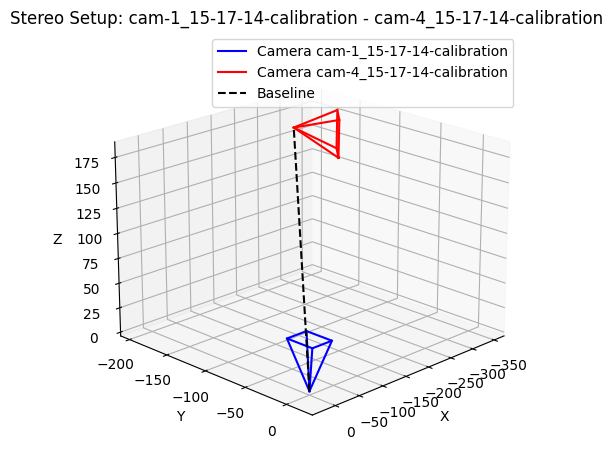

Stereo calibration saved to /mnt/c/Users/User/Documents/Studium/Bachelor/deepshapekit-v2/calibration/calib_outputs/stereo/cam-1_15-17-14-calibration__cam-4_15-17-14-calibration_stereo.json
Running stereo calibration: cam-2_15-17-14-calibration - cam-3_15-17-14-calibration
Rotation (degrees): [-92.06385426   1.25508142  84.76773561]
Translation vector: [ 143.51194784   -4.28753076 -132.70708892]
Using 14 matched frames for stereo calibration.


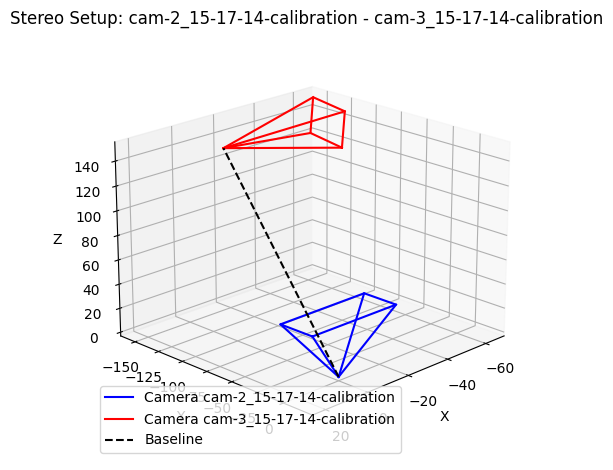

Stereo calibration saved to /mnt/c/Users/User/Documents/Studium/Bachelor/deepshapekit-v2/calibration/calib_outputs/stereo/cam-2_15-17-14-calibration__cam-3_15-17-14-calibration_stereo.json
Running stereo calibration: cam-2_15-17-14-calibration - cam-4_15-17-14-calibration
Rotation (degrees): [ 68.27996575 -38.30329996  36.96434689]
Translation vector: [ -63.79405282  144.80929238 -385.82424953]
Using 55 matched frames for stereo calibration.


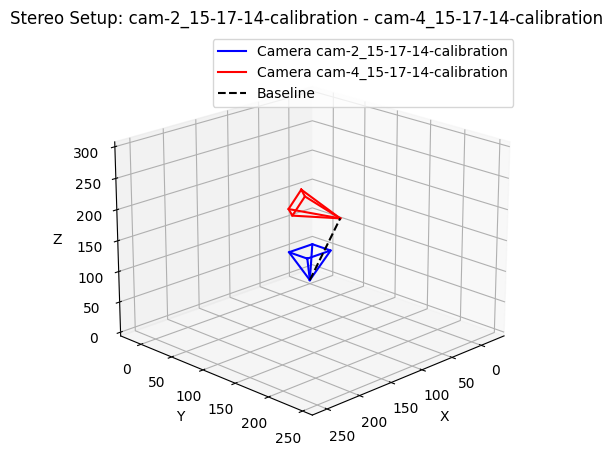

Stereo calibration saved to /mnt/c/Users/User/Documents/Studium/Bachelor/deepshapekit-v2/calibration/calib_outputs/stereo/cam-2_15-17-14-calibration__cam-4_15-17-14-calibration_stereo.json
Running stereo calibration: cam-3_15-17-14-calibration - cam-4_15-17-14-calibration
Rotation (degrees): [94.72264925  5.82084704 68.50514426]
Translation vector: [-131.86335764   53.00608003 -566.83334079]
Using 4 matched frames for stereo calibration.


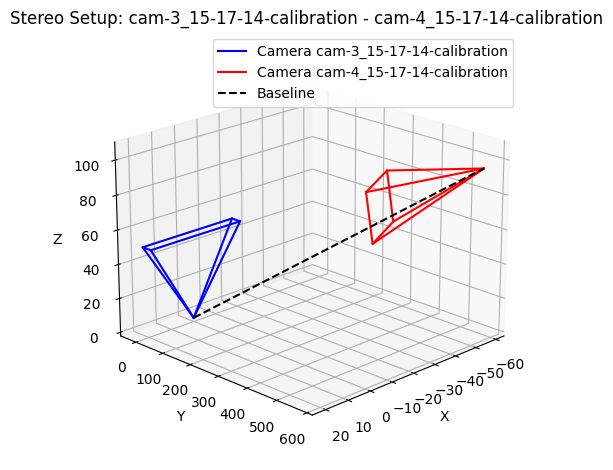

Stereo calibration saved to /mnt/c/Users/User/Documents/Studium/Bachelor/deepshapekit-v2/calibration/calib_outputs/stereo/cam-3_15-17-14-calibration__cam-4_15-17-14-calibration_stereo.json
  No alternative stereo pair found for cam-1_15-17-14-calibration; using bad ret value.


UnboundLocalError: local variable 'C2' referenced before assignment

In [36]:
# videos = [
#     '/media/jonathan/library/fish_data/bluegill_calib/cam-1/cam-1_15-17-14-calibration.avi',
#     '/media/jonathan/library/fish_data/bluegill_calib/cam-2/cam-2_15-17-14-calibration.avi',
#     '/media/jonathan/library/fish_data/bluegill_calib/cam-3/cam-3_15-17-14-calibration.avi',
#     '/media/jonathan/library/fish_data/bluegill_calib/cam-4/cam-4_15-17-14-calibration.avi'
# ]

videos = [
    '/mnt/c/Users/User/Documents/Studium/Bachelor/deepshapekit-v2/bluegill_data/videos/bluegill_calib/cam-1/cam-1_15-17-14-calibration.avi',
    '/mnt/c/Users/User/Documents/Studium/Bachelor/deepshapekit-v2/bluegill_data/videos/bluegill_calib/cam-2/cam-2_15-17-14-calibration.avi',
    '/mnt/c/Users/User/Documents/Studium/Bachelor/deepshapekit-v2/bluegill_data/videos/bluegill_calib/cam-3/cam-3_15-17-14-calibration.avi',
    '/mnt/c/Users/User/Documents/Studium/Bachelor/deepshapekit-v2/bluegill_data/videos/bluegill_calib/cam-4/cam-4_15-17-14-calibration.avi'
]
video_2_frame_number = '/mnt/c/Users/User/Documents/Studium/Bachelor/deepshapekit-v2/bluegill_data/videos/bluegill_calib/video_2_frame_number.json'
outdir = '/mnt/c/Users/User/Documents/Studium/Bachelor/deepshapekit-v2/calibration/calib_outputs'
cbrows, cbcols = 8, 9  # inner corner counts used for detection/calibration

calibrate_videos(videos, video_2_frame_number, outdir, cbrows, cbcols, frame_step=4, reorder_visualize=False, review_frames=True)